In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

# Feature Scaling

## There are two type of Feature Scaling :
### - 1. Standardization
### - 2. Normalization

#### scalling change effect
#### when we are use this method then our mean become 0 means it's come to center
#### Variance come to -1 to 1
#### we are change value of data not property we are work each row that's why it not show effect

## 1. Standardization

In [2]:
# It is a very effective technique which re-scales a feature value so that it has a distribution with a mean value of 0 and a variance equal to 1.

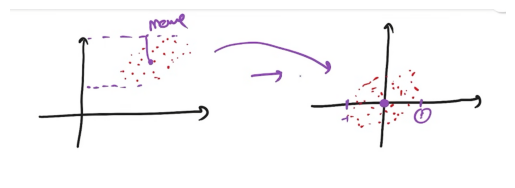

In [3]:
img = mpimg.imread('../Image/scalling_change_effect.png')
plt.imshow(img)
plt.axis('off')
plt.show()

## $$
X_{\text{new}} = \frac{X_i - \bar{X}_{\text{mean}}}{\text{Standard Deviation}}
$$

In [4]:
df = pd.read_csv('../../Dataset/loan.csv')
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [5]:
df['ApplicantIncome'] = df['ApplicantIncome'].fillna(df['ApplicantIncome'].mean())

In [6]:
before = df['ApplicantIncome']
before

0      5849
1      4583
2      3000
3      2583
4      6000
       ... 
609    2900
610    4106
611    8072
612    7583
613    4583
Name: ApplicantIncome, Length: 614, dtype: int64

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
ss = StandardScaler()

In [9]:
ss.fit(df[['ApplicantIncome']])

,copy,True
,with_mean,True
,with_std,True


In [10]:
df['ApplicantIncome_ss'] = pd.DataFrame(ss.transform(df[['ApplicantIncome']]), columns = ['x'])

In [11]:
df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_ss
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,0.072991
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,-0.134412
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,-0.393747


In [12]:
# Here we can show std**2 = variance around 1 and all data are convert in short form 
df['ApplicantIncome_ss'].describe()

count    6.140000e+02
mean    -4.339634e-18
std      1.000815e+00
min     -8.606493e-01
25%     -4.138159e-01
50%     -2.606393e-01
75%      6.414426e-02
max      1.238462e+01
Name: ApplicantIncome_ss, dtype: float64

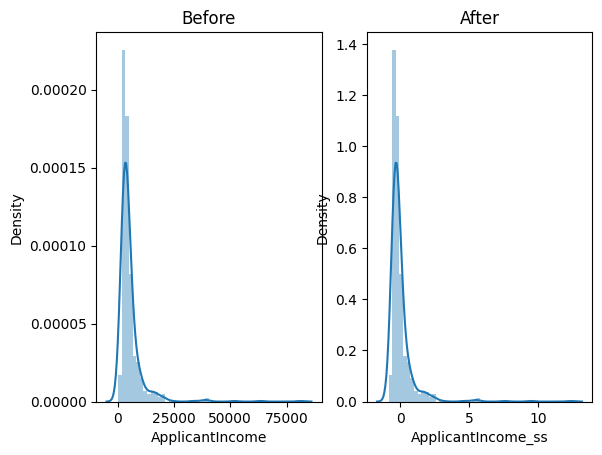

In [13]:
# Here also we can check before and now our data's beheve same as before
# Means Nature of Data are same
import warnings
warnings.filterwarnings("ignore")

before = df['ApplicantIncome']
after = df['ApplicantIncome_ss']


plt.subplot(1, 2, 1)
plt.title('Before')
sns.distplot(before)

plt.subplot(1, 2, 2)
plt.title('After')
sns.distplot(after)
plt.show()

## 2. Normalization 

In [14]:
# It is a scaling technique in which values are shifted and rescaled so that they end up ranging between 0 and 1. It is also known as Min-Max scaling.
# It's also konwn as Min-Max Scaling

## $$
X_{\text{new}} = \frac{X_i - \min(X)}{\max(X) - \min(X)}
$$

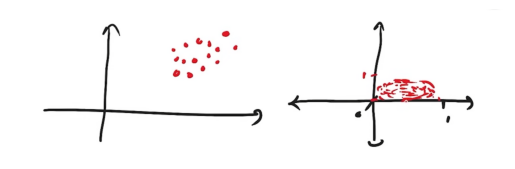

In [15]:
# in Normalization all data set x axis and y axis both of there set in 0 to 1
# here below we can see data set to x and y of them 0 to 1
img = mpimg.imread('../Image/Normalization.png')
plt.imshow(img)
plt.axis('off')
plt.show()

In [16]:
data = pd.read_csv('../../Dataset/loan.csv')
data.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [17]:
# Quick Reminder: when we are do scalling outlier still be outlier we must remove it

In [18]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
ms = MinMaxScaler()
ms.fit(data[['CoapplicantIncome']])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [20]:
data['CoapplicantIncome_MinMax'] = ms.transform(data[['CoapplicantIncome']])

In [21]:
data.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,CoapplicantIncome_MinMax
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,0.000000
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,0.036192
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,0.000000


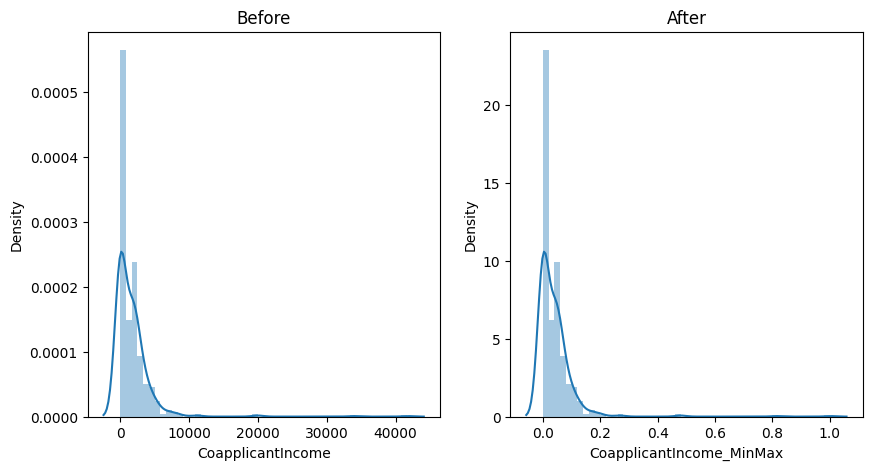

In [22]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Before')
sns.distplot(data['CoapplicantIncome'])

plt.subplot(1, 2, 2)
plt.title('After')
sns.distplot(data['CoapplicantIncome_MinMax'])

plt.show()